Neste notebook estarei criando uma rede neural do tipo Deep auto encoder, ou seja, um autoencoder com mais de uma camada oculta:

In [1]:
from torchvision import datasets
import torch
import torchvision.transforms as T
from torch import nn, optim
import matplotlib.pyplot as plt

torch.manual_seed(123)

Criação da base de dados:

In [2]:
dataset_train = datasets.MNIST('../', train = True, download = True, transform = T.ToTensor())
loader_train = torch.utils.data.DataLoader(dataset_train, batch_size = 128, shuffle = True)

dataset_test = datasets.MNIST('../', train = False, download = True, transform = T.ToTensor())
loader_test = torch.utils.data.DataLoader(dataset_train, batch_size = 128, shuffle = True)

Construção do modelo:

In [3]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [4]:
# 784 -> 128 -> 64 -> 32 -> 64 -> 128 -> 784

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(nn.Flatten(),
                                   
                                   # Codificador
                                   nn.Linear(28*28, 128),
                                   nn.ReLU(),
                                   nn.Linear(128, 64),
                                   nn.ReLU(),
                                   nn.Linear(64, 32),
                                   nn.ReLU(),

                                   # Decodificador
                                   nn.Linear(32, 64),
                                   nn.ReLU(),
                                   nn.Linear(64, 128),
                                   nn.ReLU(),
                                   nn.Linear(128, 28*28),
                                   nn.Sigmoid())
    def forward(self, X):
        return self.model(X)
    

In [5]:
model = Autoencoder().to(device)

In [6]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

Treinamento do modelo junto com o teste em cada epoch:

In [7]:
for epoch in range(20):
    # Treinamento
    total_loss_train = 0.0
    model.train()

    for inputs, _ in loader_train:
        inputs = inputs.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        targets = inputs.view(*outputs.shape)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss_train += loss.item()
    
    # Teste
    total_loss_val = 0.0
    model.eval()

    with torch.no_grad():
        for inputs, _ in loader_test:
            inputs = inputs.to(device)
            outputs = model(inputs)

            targets = inputs.view(*outputs.shape)
            loss = criterion(outputs, targets)
            
            total_loss_val += loss.item()
        
    # Final da época
    print('ÉPOCA {:3d}: perda_train {:.5f} perda_val {:.5f}'.format(epoch + 1, total_loss_train/len(loader_train), total_loss_val/len(loader_test)))

ÉPOCA   1: perda_train 0.25861 perda_val 0.19286
ÉPOCA   2: perda_train 0.16866 perda_val 0.15380
ÉPOCA   3: perda_train 0.14658 perda_val 0.14067
ÉPOCA   4: perda_train 0.13680 perda_val 0.13291
ÉPOCA   5: perda_train 0.13035 perda_val 0.12750
ÉPOCA   6: perda_train 0.12519 perda_val 0.12252
ÉPOCA   7: perda_train 0.12034 perda_val 0.11820
ÉPOCA   8: perda_train 0.11685 perda_val 0.11512
ÉPOCA   9: perda_train 0.11390 perda_val 0.11243
ÉPOCA  10: perda_train 0.11155 perda_val 0.11072
ÉPOCA  11: perda_train 0.10975 perda_val 0.10858
ÉPOCA  12: perda_train 0.10829 perda_val 0.10789
ÉPOCA  13: perda_train 0.10696 perda_val 0.10600
ÉPOCA  14: perda_train 0.10591 perda_val 0.10537
ÉPOCA  15: perda_train 0.10504 perda_val 0.10438
ÉPOCA  16: perda_train 0.10424 perda_val 0.10377
ÉPOCA  17: perda_train 0.10352 perda_val 0.10296
ÉPOCA  18: perda_train 0.10286 perda_val 0.10229
ÉPOCA  19: perda_train 0.10227 perda_val 0.10172
ÉPOCA  20: perda_train 0.10159 perda_val 0.10101


Criação do encoder com base no autoencoder:

In [10]:
list(model.children())[0]

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=32, bias=True)
  (6): ReLU()
  (7): Linear(in_features=32, out_features=64, bias=True)
  (8): ReLU()
  (9): Linear(in_features=64, out_features=128, bias=True)
  (10): ReLU()
  (11): Linear(in_features=128, out_features=784, bias=True)
  (12): Sigmoid()
)

In [12]:
class Encoder(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        # Apenas camadas de 0 a 7 do Autoencoder.
        self.model = nn.Sequential(*list(autoencoder.children())[0][:7])

    def forward(self, X):
        return self.model(X)

In [16]:
encoder = Encoder(model).to(device)

Criação do decoder com base no autoencoder:

In [21]:
class Decoder(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        # Apenas camadas de 7 a 12 do Autoencoder.
        self.model = nn.Sequential(*list(autoencoder.children())[0][7:])

    def forward(self, X):
        return self.model(X)

In [20]:
decoder = Decoder(model).to(device)

Visualização dos resultados:

In [22]:
numero_imagens = 20
# Pega 20 imagens do batch 0
imagens_teste = (next(iter(loader_test))[0][:numero_imagens]).to(device)

Codificação das imagens:

In [23]:
encoder.eval()
imagens_codificadas = encoder(imagens_teste)

Decodificação das imagens:

In [24]:
decoder.eval()
imagens_decodificadas = decoder(imagens_codificadas)

In [25]:
imagens_teste_plt = imagens_teste.view(-1, 28, 28).detach().cpu().numpy()

In [26]:
imagens_codificadas_plt = imagens_codificadas.view(-1, 8, 4).detach().cpu().numpy()

In [27]:
imagens_decodificadas_plt = imagens_decodificadas.view(-1, 28, 28).detach().cpu().numpy()

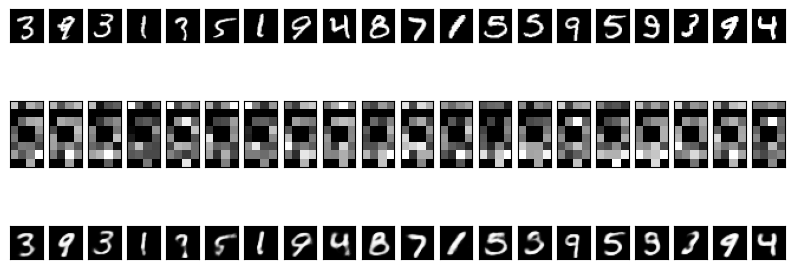

In [28]:
fig, axes = plt.subplots(nrows = 3, ncols = numero_imagens, figsize = (10, 4))
for imagens, ax_row in zip([imagens_teste_plt, imagens_codificadas_plt, imagens_decodificadas_plt], axes):
    for img, ax in zip(imagens, ax_row):
        ax.imshow(img, cmap = 'gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)